## Omnimind Agent System

In [2]:
import os
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from typing import TypedDict
import ast
import numpy as np

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### LLM

In [3]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001D07AAF4550>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D07B00A650>, root_client=<openai.OpenAI object at 0x000001D07AAF4090>, root_async_client=<openai.AsyncOpenAI object at 0x000001D07B00A150>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Agent State

In [4]:
class AgentState(TypedDict):
    query: str
    route: str
    
    math_result: str
    code_result: str
    data_result: str
    summary_result: str
    general_result: str
    
    final_result: str
    
    retries: int
    valid: bool
    
AgentState

__main__.AgentState

### Tools

#### Percentage

In [5]:
@tool
def percentage_calc_tool(value: float, percentage: float) -> str:
    '''Calculate Percentage'''
    
    print('\n[TOOL: Percentage Calculator]')
    try:
        return str((value*percentage)/100)
    except Exception as e:
        return f"Claculation Error {e}"

#### Mean

In [6]:
@tool
def calculate_mean_tool(numbers: str) -> str:
    '''Calculates mean of numbers separated by comma'''

    print('\n[TOOL: Calculate Mean]')
    try:
        nums= np.array(numbers.split(',')).astype(float)
        return nums.mean()
    except Exception as e:
        return f'Mean Error {e}'

#### Code Validator

In [7]:
@tool
def code_validator_tool(code: str) -> str:
    '''Validates Python code using AST parsing'''

    print('\n[TOOL: Code Validator]')
    try:
        ast.parse(code)
        return "Code issyntactically valid"
    except SyntaxError as e:
        return f"Syntax Error: {e}"
    except IndentationError as e:
        return f'Indentation Error: {e}'
    except Exception as e:
        print(f'Code Validation Error: {e}')

#### Keyword Extractor

In [8]:
@tool
def keyword_extractor_tool(text: str) -> str:
    '''Extracts first 5 words from the given text'''
    
    print('\n[TOOL: Keyword Extractor]')
    try:
        return ','.join(text.split(',')[:5])
    except Exception as e:
        return f'Keyword Extraction Error: {e}'

### Agents

#### Math Agent

In [10]:
math_agent = create_agent(
    model=llm,
    tools=[percentage_calc_tool],

    system_prompt='''You are a math expert. You always use the given tool when needed.'''
)

#### Coding Agent

In [11]:
coding_agent = create_agent(
    model=llm,
    tools=[code_validator_tool],
    
    system_prompt='''You are a coding expert.
    Generate correct Python code and always validate it with the given tool'''
)

#### Data Analysis Agent

In [13]:
data_agent = create_agent(
    model=llm,
    tools=[calculate_mean_tool, keyword_extractor_tool],
    
    system_prompt='''You are a data analyst.
    Always use the given tools to analyse the data and to extract the keywords as needed'''
)

#### Summary Agent

In [14]:
summary_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful assistant.
    Summarise the given text simply and precisly without losing the main context and the information given in the text. '''
)

#### General Agent

In [15]:
general_agent = create_agent(
    model=llm,
    tools=[],
    
    system_prompt='''You are a helpful assistant. You answer the general queries very briefly with in 100 words.'''
)

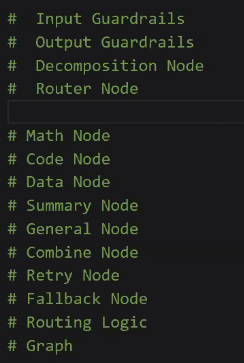

### Nodes

In [28]:
def input_guardrails_node(state):
    print('\n[INPUT GUARDRAILS NODE] ', state['query'])
    query = state['query']
        
    # Empty check
    if not query.strip():
        return {'valid': False}
    
    # Keyword check
    banned_keywords = ['hack', 'attack', 'illegal', 'ignore instructions', 'no restrictions', 'system prompt']
    if any(word in query.lower() for word in banned_keywords):
        return {'valid': False}
    
    return {'valid': True}

In [17]:
def output_guardrails_node(state):
    print('\n[OUTPUT GUARDRAILS NODE]')
    final_result = state['final_result']
    
    # Empty check
    if not final_result.strip():
        return {'valid': False}
    
    return {'valid': True}

In [18]:
def decomposition_node(state):
    print('\n[DECOMPOSITION NODE]')
    query = state['query']
    
    prompt = f'''Break the given query into smaller tasks. 
QUERY:
{query}

Return only a Python list of strings. No explanation, no markdown.
Example: ['Task 1', 'Task 2', 'Task 3']
'''

    result = llm.invoke(prompt).content.strip()
    result = ast.literal_eval(result) # convert to list
    print('[DECOMPOSED TASKS]')
    print(result)
    return result

In [19]:
def router_node(state):
    print('\n[ROUTER NODE]')
    
    prompt = f'''Decide which agent(s) to use based upon the given query. Return only the agent name.
    
AGENTS:
    - math (math related questions)
    - coding (python coding questions)
    - data analysis
    - summary
    - general

QUERY:
{state['query']}'''

    decision = llm.invoke(prompt).content.strip()
    print('\Route: ', decision)
    
    return {'route': decision}

In [20]:
def math_node(state):
    """Solve the given math problem"""
    
    print('\n[MATH NODE]')

    result = math_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'math_result': answer}

In [21]:
def coding_node(state):
    """Solve the given math problem"""
    
    print('\n[CODING NODE]')

    result = coding_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'code_result': answer}

In [22]:
def data_analysis_node(state):
    """Solve the given math problem"""
    
    print('\n[DATA ANALYSIS NODE]')

    result = data_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'data_result': answer}

In [23]:
def summary_node(state):
    """Solve the given math problem"""
    
    print('\n[SUMMARY NODE]')

    result = summary_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'summary_result': answer}

In [24]:
def general_node(state):
    """Solve the given math problem"""
    
    print('\n[GENERAL NODE]')

    result = general_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'general_result': answer}

### Flow

In [25]:
graph = StateGraph(AgentState)

graph.add_node('input_guardrails_n', input_guardrails_node)
graph.add_node('output_guardrails_n', output_guardrails_node)
graph.add_node('decomposition_n', decomposition_node)
graph.add_node('router_n', router_node)
graph.add_node('math_n', math_node)
graph.add_node('coding_n', coding_node)
graph.add_node('data_analysis_n', data_analysis_node)
graph.add_node('summary_n', summary_node)
graph.add_node('general_n', general_node)